:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`glm_for_classification.ipynb`**!

:::


# Fit GLM for Classification

The [`ClassifierGLM`](nemos.glm.ClassifierGLM) models categorical or discrete outcomes such as behavioral choices.

**Key differences from standard GLM:**
- [`predict`](nemos.glm.ClassifierGLM.predict) returns predicted class labels
- [`predict_proba`](nemos.glm.ClassifierGLM.predict_proba) returns (log-)probabilities for each class
- [`set_classes`](nemos.glm.ClassifierGLM.set_classes) set class labels. By Default, classes are assumed to be `{0, ..., n_classes - 1}` however, this assumption can be overridden by calling `set_classes` passing an array of class labels.
- The `observation_model` parameter cannot be set at model initialization, since [`CategoricalObservations`](nemos.observation_models.CategoricalObservations) is the only compatible observation model.

## Generate Synthetic Data

In this example, we simulate categorical choice data to demonstrate the classifier. With real data, you would replace this section by loading your experimental observations.

In [1]:
import jax
import numpy as np
import nemos as nmo

np.random.seed(200)

n_samples, n_features, n_classes = 1000, 5, 3
X = np.random.randn(n_samples, n_features)

# simulate categorical choices using known coefficients
true_coef = 2 * np.random.randn(n_features, n_classes)
true_intercept = np.zeros(n_classes)

model = nmo.glm.ClassifierGLM(n_classes)
model.coef_ = true_coef
model.intercept_ = true_intercept
# set classes
model.set_classes(np.arange(n_classes))
true_choice, _ = model.simulate(jax.random.PRNGKey(124), X)

## Fit the Model and Predict Choices

In [2]:
model = nmo.glm.ClassifierGLM(n_classes)

train_samples = 500
model.fit(X[:train_samples], true_choice[:train_samples])

# predict
predicted_choice = model.predict(X)

# get class probabilities
probs = model.predict_proba(X)
print(f"Probability shape: {probs.shape}")  # (n_samples, n_classes)

Probability shape: (1000, 3)


## Visualize Results

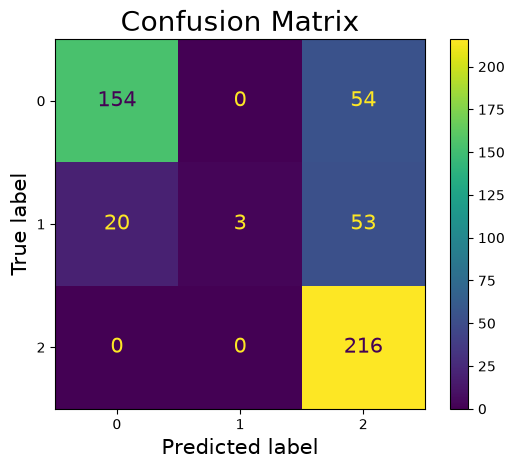

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(true_choice[train_samples:], predicted_choice[train_samples:])
disp = ConfusionMatrixDisplay(cm)
disp.plot(text_kw=dict(fontsize=15))
plt.title("Confusion Matrix", fontsize=20)
plt.xlabel(disp.ax_.get_xlabel(), fontsize=15)
plt.ylabel(disp.ax_.get_ylabel(), fontsize=15)
plt.show()

In [4]:
# save image for thumbnail
from pathlib import Path
import os

fig = disp.figure_
root = os.environ.get("READTHEDOCS_OUTPUT")
if root:
   path = Path(root) / "html/_static/thumbnails/how_to_guide"
# if local store in ../_build/html/...
else:
   path = Path("../_build/html/_static/thumbnails/how_to_guide")

# make sure the folder exists if run from build
if root or Path("../assets/stylesheets").exists():
   path.mkdir(parents=True, exist_ok=True)

if path.exists():
  fig.savefig(path / "glm_for_classification.svg")